In [157]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [73]:
df = pd.read_csv("C:/Users/user/Documents/EBAC/dados/CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


In [74]:
# Etapa 1: Relize os passos que vimos no módulo 18, de pré processamento dos dados.

In [75]:
# A) Verifique os tipos de dados, fazendo as transformações quando necessário.

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    float64
 1   Gender              164 non-null    object 
 2   Income              164 non-null    object 
 3   Education           164 non-null    object 
 4   Marital Status      164 non-null    object 
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    object 
 7   Credit Score        164 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 10.4+ KB


In [77]:
# Income deve ser entendido como float por tratar-se de um valor monetário

In [78]:
# Existe um problema na formatação do número. O Python não consegue converter diretamente uma string com pontos para separar milhares e vírgulas como separador decimal para um número float.

# Foi necessário tomar a seguinte modificação:
# Substituir pontos por nada (remover separadores de milhar):

# Primeiro, removendo os pontos que separam os milhares.
# Em seguida, substituir a vírgula por um ponto (o separador decimal padrão do Python).
# Finalmente podemos converta a string resultante para float.

df['Income'] = df['Income'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    float64
 1   Gender              164 non-null    object 
 2   Income              164 non-null    float64
 3   Education           164 non-null    object 
 4   Marital Status      164 non-null    object 
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    object 
 7   Credit Score        164 non-null    object 
dtypes: float64(2), int64(1), object(5)
memory usage: 10.4+ KB


In [80]:
# B) Verifique se temos colunas com dados faltantes.
# Caso existam colunas com dados faltantes faça o tratamento desses dados, excluindo ou substituindo esses valores. Justifique sua escolha.

In [81]:
df.isnull().sum() # numero de valores nulos por coluna

Age                   34
Gender                 0
Income                 0
Education              0
Marital Status         0
Number of Children     0
Home Ownership         0
Credit Score           0
dtype: int64

In [82]:
(df.isnull().sum() / len(df)) * 100 # descobrindo a porcentagem dos nulos

Age                   20.731707
Gender                 0.000000
Income                 0.000000
Education              0.000000
Marital Status         0.000000
Number of Children     0.000000
Home Ownership         0.000000
Credit Score           0.000000
dtype: float64

In [83]:
# A coluna 'Age' conta com 20% de dados nulos. isto representa 1/4 do dataset. Considero isto um valor expressivo, portanto, tomarei a decisao de adequar os dados faltantes à media ou mediana desta coluna

In [84]:
media_Age = df['Age'].mean() #media
media_Age

37.50769230769231

In [85]:
mediana_Age = df['Age'].median() #mediana
mediana_Age

36.0

In [86]:
# Como a media e a mediana apresentam valores próximos, optamos por substituir os valores faltantes pela média

In [87]:
df['Age'] = df['Age'].fillna(media_Age) #substituindo os valores nulos pela media

In [88]:
df.isnull().sum() # Verificando se ainda existem valores nulos

Age                   0
Gender                0
Income                0
Education             0
Marital Status        0
Number of Children    0
Home Ownership        0
Credit Score          0
dtype: int64

In [89]:
#C) Verifique se temos valores digitados de forma incorreta nas variáveis categóricas que necessitem de tratamento.

In [90]:
df['Gender'].unique() # Verificando formas 'unicas' que podem ter sido inseridas

array(['Female', 'Male'], dtype=object)

In [91]:
df['Education'].unique() # Verificando formas 'unicas' que podem ter sido inseridas

array(["Bachelor's Degree", "Master's Degree", 'Doctorate',
       'High School Diploma', "Associate's Degree"], dtype=object)

In [92]:
df['Marital Status'].unique() # Verificando formas 'unicas' que podem ter sido inseridas

array(['Single', 'Married'], dtype=object)

In [93]:
df['Home Ownership'].unique() # Verificando formas 'unicas' que podem ter sido inseridas

array(['Rented', 'Owned'], dtype=object)

In [94]:
df['Credit Score'].unique() # Verificando formas 'unicas' que podem ter sido inseridas

array(['High', 'Average', 'Low'], dtype=object)

In [95]:
# Nenhum valor está escrito de forma incorreta!

In [96]:
# Etapa 2: Relize os passos que vimos no módulo 15, de análise.

In [97]:
# A) Realiza a análise univariada, aplique a função describe ao nosso dataframe para verificar os dados das variáveis numéricas, 
# se encontrar a possível presença de outliers analise com gráficos a distribuição dos dados.Traga insights sobre os dados analisados.

In [98]:
df.describe() # exibe o panorama das nossas variáveis quantitativas (numéricas)

,Age,Income,Number of Children
count,164.000000,164.000000,164.000000
mean,37.507692,83765.243902,0.652439
std,7.561808,32457.306728,0.883346
min,25.000000,25000.000000,0.000000
25%,31.750000,57500.000000,0.000000
50%,37.507692,83750.000000,0.000000
75%,43.000000,105000.000000,1.000000
max,53.000000,162500.000000,3.000000


In [99]:
# é possível ver que não existe forte presença de outliers pois os dados estão bem distribuidos

In [100]:
# B) Agora realize a análise univariada para as variaveis categóricas, 
# plote gráficos para entender a distribuição das categorias e tente retirar insights de cada gráfico.

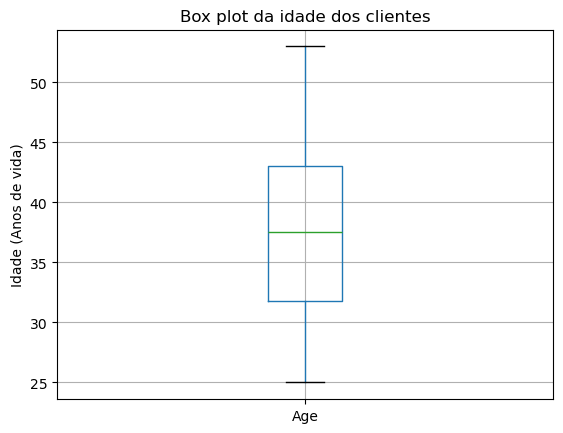

In [101]:
df.boxplot(column='Age')
plt.title('Box plot da idade dos clientes')
plt.ylabel('Idade (Anos de vida)')
plt.show()

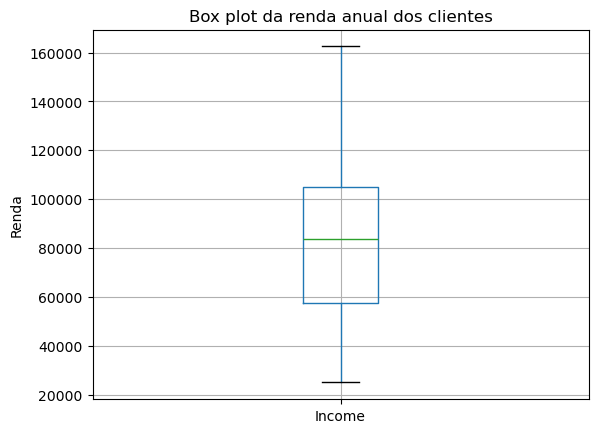

In [102]:
df.boxplot(column='Income')
plt.title('Box plot da renda anual dos clientes')
plt.ylabel('Renda')
plt.show()

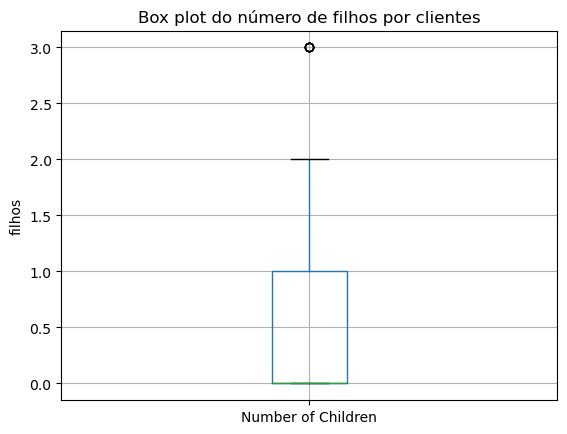

In [103]:
df.boxplot(column='Number of Children')
plt.title('Box plot do número de filhos por clientes')
plt.ylabel('filhos')
plt.show()

In [104]:
# É possível identificar um outlier neste último plot, porém não parece justo tratá-lo como outlier considerando que a variável é int e estende-se de
# 1 a 3. ou seja, não seria viável tratar o valor 3 como um outlier.

In [105]:
# B) Agora realize a análise univariada para as variaveis categóricas, plote gráficos para entender a distribuição das categorias e 
    # tente retirar insights de cada gráfico.

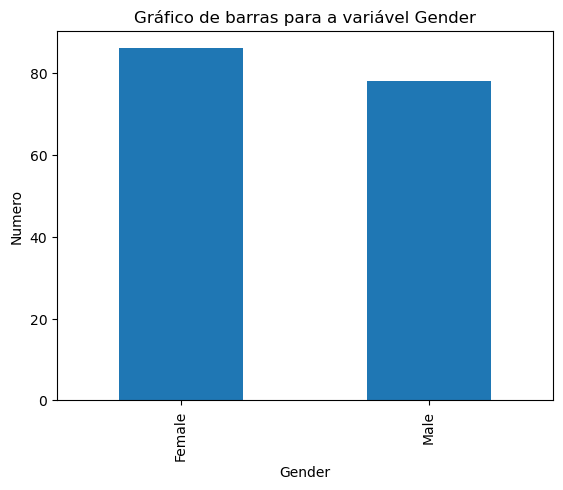

In [106]:
# Contagem dos valores da coluna Gender

contagem_Gender = df['Gender'].value_counts()

# Calculando a porcentagem para que apareça no grafico

porcentagem_Gender = (contagem_Gender / contagem_Gender.sum()) * 100
ax = contagem_Gender.plot(kind='bar')
plt.title('Gráfico de barras para a variável Gender')
plt.xlabel('Gender')
plt.ylabel('Numero')
plt.show()

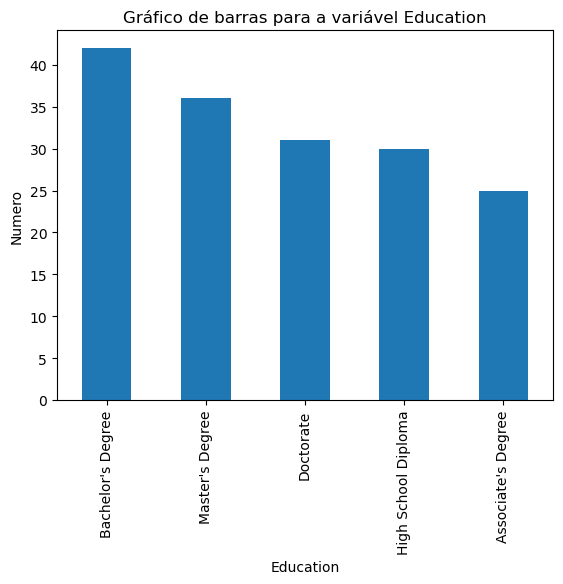

In [107]:
# Contagem dos valores da coluna Education

contagem_Education = df['Education'].value_counts()

# Calculando a porcentagem para que apareça no grafico

porcentagem_Education = (contagem_Education / contagem_Education.sum()) * 100
ax = contagem_Education.plot(kind='bar')
plt.title('Gráfico de barras para a variável Education')
plt.xlabel('Education')
plt.ylabel('Numero')
plt.show()

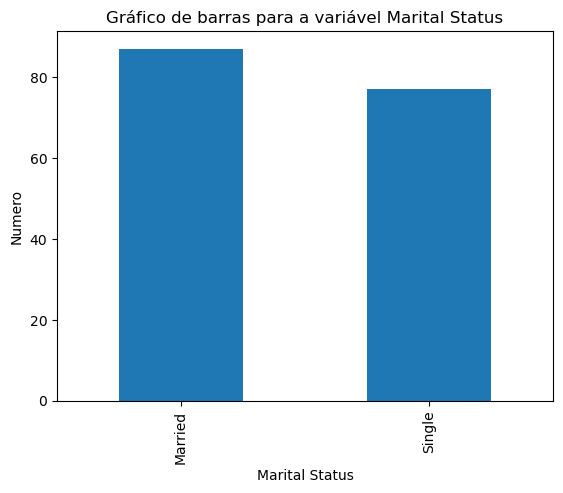

In [108]:
# Contagem dos valores da coluna Marital Status

contagem_Marital_Status = df['Marital Status'].value_counts()

# Calculando a porcentagem para que apareça no grafico

porcentagem_Marital_Status = (contagem_Marital_Status / contagem_Marital_Status.sum()) * 100
ax = contagem_Marital_Status.plot(kind='bar')
plt.title('Gráfico de barras para a variável Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Numero')
plt.show()

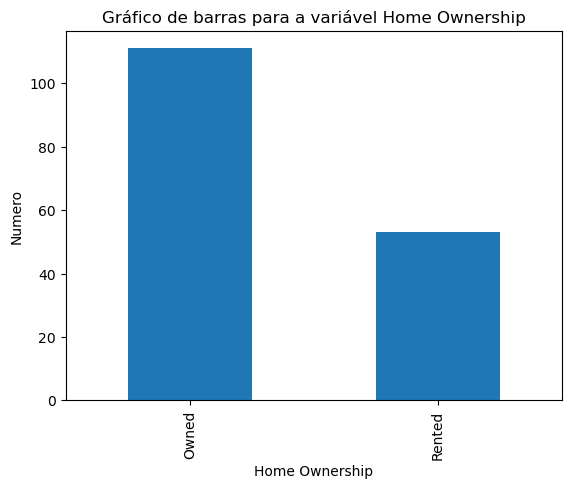

In [109]:
# Contagem dos valores da coluna Home Ownership

contagem_Home_Ownership = df['Home Ownership'].value_counts()

# Calculando a porcentagem para que apareça no grafico

porcentagem_Home_Ownership = (contagem_Home_Ownership / contagem_Home_Ownership.sum()) * 100
ax = contagem_Home_Ownership.plot(kind='bar')
plt.title('Gráfico de barras para a variável Home Ownership')
plt.xlabel('Home Ownership')
plt.ylabel('Numero')
plt.show()

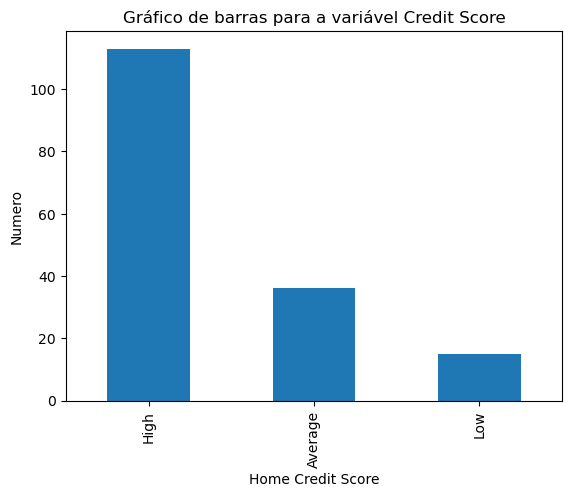

In [110]:
# Contagem dos valores da coluna Home Credit Score

contagem_Credit_Score = df['Credit Score'].value_counts()

# Calculando a porcentagem para que apareça no grafico

porcentagem_Credit_Score = (contagem_Credit_Score / contagem_Credit_Score.sum()) * 100
ax = contagem_Credit_Score.plot(kind='bar')
plt.title('Gráfico de barras para a variável Credit Score')
plt.xlabel('Home Credit Score')
plt.ylabel('Numero')
plt.show()

In [111]:
# C) Você encontrou alguma coluna com outliers? Se sim realize o tratamento desses casos.

In [112]:
# Encontrei no plot da variável Number of Children e, como expliquei, não acho válido ou viável trata-lá como outlier por nao destoar dos dados e não apresentar discrepância

In [113]:

# D) Realize a análise Bivariada.
# Tente responder as seguintes perguntas com gráficos seguidos de insights:



#* Existe relação entre a idade e o status civil?
#* Qual a relação entre o score de crédito e o nível de escolaridade?
#* O salário parece influenciar na idade?
#* O salário parece influenciar no Score de Crédito?
#* Clientes com casa própria tendem a ter um score mais alto?




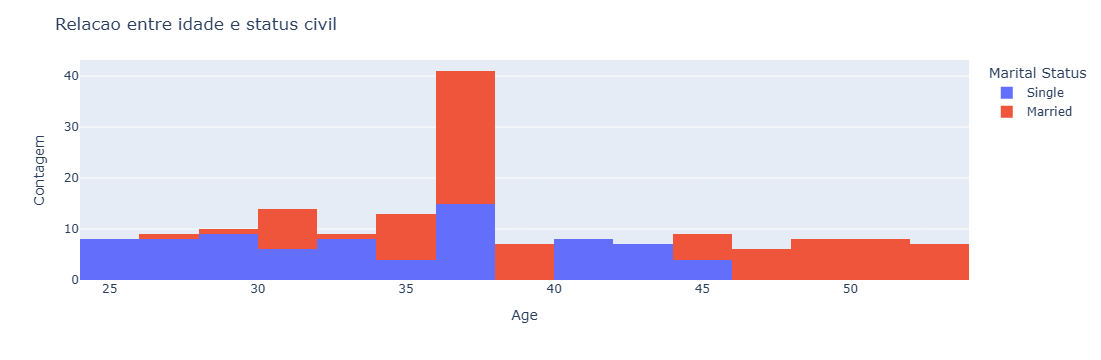

In [114]:
# idade x status civil

fig = px.histogram(df, x='Age', color='Marital Status', barmode='stack')

# Layout
fig.update_layout(title='Relacao entre idade e status civil',
		  xaxis_title='Age',
		  yaxis_title='Contagem',
		  legend_title='Marital Status')
fig.show()

In [115]:
# É possível indentificar que, a apartir dos 35 a maioria do dataset corresponde a casados

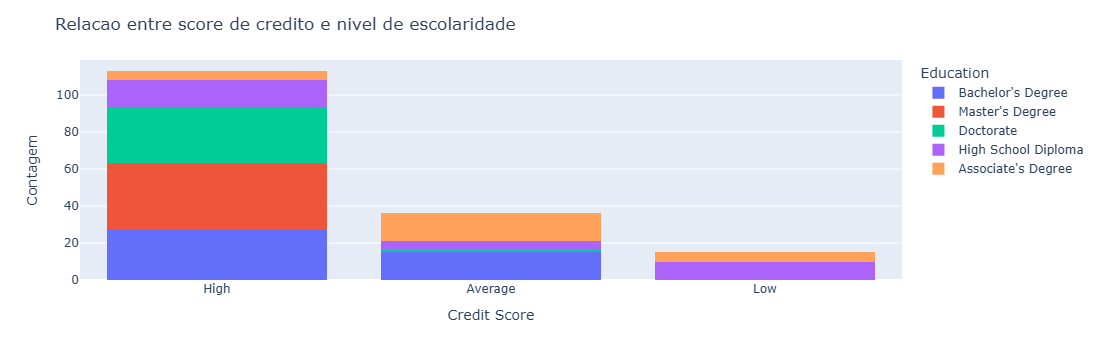

In [116]:
# score de credito x nivel de escolaridade

fig = px.histogram(df, x='Credit Score', color='Education', barmode='stack')

# Layout
fig.update_layout(title='Relacao entre score de credito e nivel de escolaridade',
		  xaxis_title='Credit Score',
		  yaxis_title='Contagem',
		  legend_title='Education')
fig.show()

In [117]:
# Analisamos que Doutores possuem em maioria absoluta um alto nivel de credito

# enquanto que, a baixa linha de credito corresponde somente aos niveis de escolaridade mais baixa

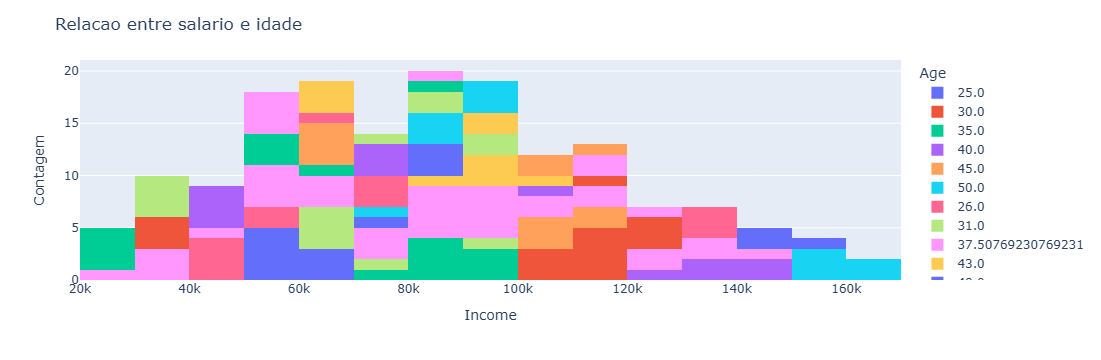

In [118]:
# salario x idade

fig = px.histogram(df, x='Income', color='Age', barmode='stack')

# Layout
fig.update_layout(title='Relacao entre salario e idade',
		  xaxis_title='Income',
		  yaxis_title='Contagem',
		  legend_title='Age')
fig.show()

In [119]:
# É possivel afirmar que os salários tendem a subir na medida que a idade avança 

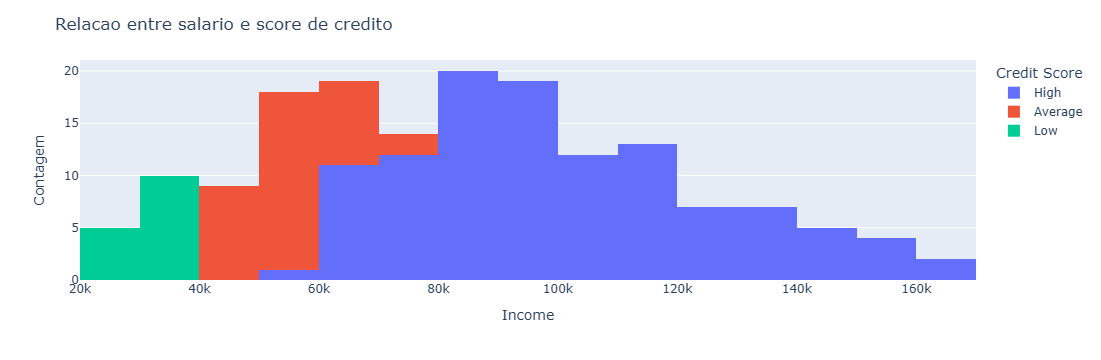

In [120]:
# salario x score de credito

fig = px.histogram(df, x='Income', color='Credit Score', barmode='stack')

# Layout
fig.update_layout(title='Relacao entre salario e score de credito',
		  xaxis_title='Income',
		  yaxis_title='Contagem',
		  legend_title='Credit Score')
fig.show()

In [121]:
# Nitidamente os maiores salários possuem mais score de credito

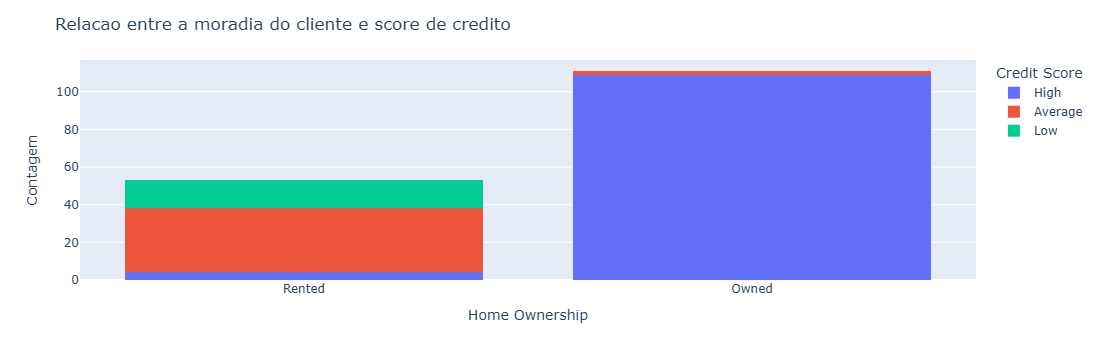

In [122]:
# moradia x score de credito

fig = px.histogram(df, x='Home Ownership', color='Credit Score', barmode='stack')

# Layout
fig.update_layout(title='Relacao entre a moradia do cliente e score de credito',
		  xaxis_title='Home Ownership',
		  yaxis_title='Contagem',
		  legend_title='Credit Score')
fig.show()

In [123]:
# Os clientes com casa própria representam quase que toda base de dados correspondente ao high score

In [124]:
# Etapa 3: Relize os passos que vimos no módulo 17, de Correlação, Balanceamento, atributos categóricos e divisão base treino e teste.

In [125]:
# A) Vamos começar pela análise de correlação, plote da forma que achar melhor a análise de correlação, seja pela tabela ou pelo gráfico da matriz.

In [126]:
# Matriz de correlacao

df.select_dtypes(include=['number']).corr() # correlacao apenas entre as variaveis numericas

,Age,Income,Number of Children
Age,1.000000,0.620968,0.071032
Income,0.620968,1.000000,0.084547
Number of Children,0.071032,0.084547,1.000000


In [127]:
# B) Você encontrou variáveis que tem uma média ou alta correlação? Se sim, quais? Te parece fazer sentido essas variáveis terem alta correlação? Justifique.

In [128]:
# Age possui forte correlacao com Income, mostrando que a idade influencia fortemente na renda, como ja foi demonstrado anteriormente

# Age possui baixa correlacao com numero de filhos demonstrando a baixa capacidade de influencia neste ponto de uma para a outra

# income e numero de filhos apresentam baixa correlacao tambem demonstrando baixa capacidade de influencia de um dado no outro

In [129]:
# C) Temos muitos atributos categóricos nessa base, não? Vamos realizar a o tratamento desses atributos utilizando Label Encoder ou one hot. Após, 
# exclua as colunas categóricas.

In [130]:
# Criando uma instancia de LabelEncoder

label_encoder = LabelEncoder()

# Aplicando a label encoder para a coluna Marital Status
df['Marital_Status_Encoded'] = label_encoder.fit_transform(df['Marital Status'])
# Aplicando a label encoder para a coluna Gender
df['Gender_Encoded'] = label_encoder.fit_transform(df['Gender'])
# Aplicando a label encoder para a coluna Gender
df['Home_Ownership_Encoded'] = label_encoder.fit_transform(df['Home Ownership'])
# Aplicando a label encoder para a coluna Gender
df['Credit_Score_Encoded'] = label_encoder.fit_transform(df['Credit Score'])

# Aplicando o one hot para a coluna Education - neste caso nao criamos instancia
df = pd.get_dummies(df, columns=['Education'], prefix='Education', drop_first=True)

#df = pd.get_dummies(df, colums=['Education'], prefix='Education') esta funcao transofrma a coluna 'Education' em varias colunas binarias (one-hot encoded)


print (df)

      Age  Gender    Income Marital Status  Number of Children Home Ownership  \
0    25.0  Female   50000.0         Single                   0         Rented   
1    30.0    Male  100000.0        Married                   2          Owned   
2    35.0  Female   75000.0        Married                   1          Owned   
3    40.0    Male  125000.0         Single                   0          Owned   
4    45.0  Female  100000.0        Married                   3          Owned   
..    ...     ...       ...            ...                 ...            ...   
159  29.0  Female   27500.0         Single                   0         Rented   
160  34.0    Male   47500.0         Single                   0         Rented   
161  39.0  Female   62500.0        Married                   2          Owned   
162  44.0    Male   87500.0         Single                   0          Owned   
163  49.0  Female   77500.0        Married                   1          Owned   

    Credit Score  Marital_S

In [131]:
# A coluna 'Average' foi excluida diretamente por ser aquilo que representa quando todos os outros campos em Education serem False

In [132]:
df.dtypes

Age                              float64
Gender                            object
Income                           float64
Marital Status                    object
Number of Children                 int64
Home Ownership                    object
Credit Score                      object
Marital_Status_Encoded             int32
Gender_Encoded                     int32
Home_Ownership_Encoded             int32
Credit_Score_Encoded               int32
Education_Bachelor's Degree         bool
Education_Doctorate                 bool
Education_High School Diploma       bool
Education_Master's Degree           bool
dtype: object

In [133]:
# convertendo os bool's de education para int
for column in df.columns:
    if df[column].dtype == 'bool':
        df[column] = df[column].astype(int)
print(df)

      Age  Gender    Income Marital Status  Number of Children Home Ownership  \
0    25.0  Female   50000.0         Single                   0         Rented   
1    30.0    Male  100000.0        Married                   2          Owned   
2    35.0  Female   75000.0        Married                   1          Owned   
3    40.0    Male  125000.0         Single                   0          Owned   
4    45.0  Female  100000.0        Married                   3          Owned   
..    ...     ...       ...            ...                 ...            ...   
159  29.0  Female   27500.0         Single                   0         Rented   
160  34.0    Male   47500.0         Single                   0         Rented   
161  39.0  Female   62500.0        Married                   2          Owned   
162  44.0    Male   87500.0         Single                   0          Owned   
163  49.0  Female   77500.0        Married                   1          Owned   

    Credit Score  Marital_S

In [134]:
# Dropar a coluna Marital Status 
df = df.drop(['Marital Status'], axis=1)
print(df)

# Dropar a coluna Gender 
df = df.drop(['Gender'], axis=1)
print(df)

# Dropar a coluna Home Ownership 
df = df.drop(['Home Ownership'], axis=1)
print(df)

# Dropar a coluna Credit Score
df = df.drop(['Credit Score'], axis=1)
print(df)

      Age  Gender    Income  Number of Children Home Ownership Credit Score  \
0    25.0  Female   50000.0                   0         Rented         High   
1    30.0    Male  100000.0                   2          Owned         High   
2    35.0  Female   75000.0                   1          Owned         High   
3    40.0    Male  125000.0                   0          Owned         High   
4    45.0  Female  100000.0                   3          Owned         High   
..    ...     ...       ...                 ...            ...          ...   
159  29.0  Female   27500.0                   0         Rented          Low   
160  34.0    Male   47500.0                   0         Rented      Average   
161  39.0  Female   62500.0                   2          Owned         High   
162  44.0    Male   87500.0                   0          Owned         High   
163  49.0  Female   77500.0                   1          Owned         High   

     Marital_Status_Encoded  Gender_Encoded  Home_O

In [135]:
# D) Vamos plotar novamente a correlação, agora observando com as variáveis categóricas. Identifique se temos novas variáveis com forte correlação.

In [136]:
df.corr()

,Age,Income,Number of Children,Marital_Status_Encoded,Gender_Encoded,Home_Ownership_Encoded,Credit_Score_Encoded,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree
Age,1.000000,0.620968,0.071032,-0.452943,0.204916,-0.635286,0.226747,-0.135761,0.189676,-0.004538,0.093346
Income,0.620968,1.000000,0.084547,-0.471004,0.495738,-0.704928,0.083698,-0.079067,0.060776,-0.061150,0.344382
Number of Children,0.071032,0.084547,1.000000,-0.696984,-0.442139,-0.497129,0.136517,0.310881,0.102117,-0.260999,0.092207
Marital_Status_Encoded,-0.452943,-0.471004,-0.696984,1.000000,0.278362,0.708374,-0.205756,-0.132109,-0.266960,0.186919,-0.026638
Gender_Encoded,0.204916,0.495738,-0.442139,0.278362,1.000000,-0.031519,-0.247729,-0.223104,-0.272675,0.023108,0.379875
Home_Ownership_Encoded,-0.635286,-0.704928,-0.497129,0.708374,-0.031519,1.000000,-0.293384,0.072490,-0.300305,0.178899,-0.334958
Credit_Score_Encoded,0.226747,0.083698,0.136517,-0.205756,-0.247729,-0.293384,1.000000,-0.247661,0.085207,0.256927,0.125118
Education_Bachelor's Degree,-0.135761,-0.079067,0.310881,-0.132109,-0.223104,0.072490,-0.247661,1.000000,-0.283269,-0.277621,-0.311165
Education_Doctorate,0.189676,0.060776,0.102117,-0.266960,-0.272675,-0.300305,0.085207,-0.283269,1.000000,-0.228435,-0.256036
Education_High School Diploma,-0.004538,-0.061150,-0.260999,0.186919,0.023108,0.178899,0.256927,-0.277621,-0.228435,1.000000,-0.250931


In [137]:
# forte correlacao entre Age e income, income e gender, Marital_Status e gender, Marital_Status e 	Home_Ownership, Education_Master's Degree e Gender

In [138]:
# F) Faça a separação da base em treino e teste e verifique utilizando shape:

In [142]:
# Separar os dados em features (X) e o alvo (Y)
X = df.drop('Credit_Score_Encoded', axis=1) # Considerando que 'Credit_Score_Encoded' é a coluna a ser predita
Y = df['Credit_Score_Encoded']

In [145]:
# Separar os dados em conjuntos de treino e teste

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

# O parametro 'test_size' determina a proporcao dos dados que serao separados para teste (25% neste exemplo)
# o parametro 'random_state' é usado para garantir que a divisao seja reproduzivel

In [146]:
print ('Tamanho de X_train:', X_train.shape)

Tamanho de X_train: (123, 10)


In [147]:
print ('Tamanho de Y_train:', Y_train.shape)

Tamanho de Y_train: (123,)


In [148]:
print ('Tamanho de X_test:', X_test.shape)

Tamanho de X_test: (41, 10)


In [149]:
print ('Tamanho de Y_test:', Y_test.shape)

Tamanho de Y_test: (41,)


In [ ]:
# numero de linhas perfeitamente igual entre X em treino e teste e em Y entre treino e teste

In [ ]:
# G) É hora de verificar se nossa coluna de Score de crédito está balanceada, verifique através de um gráfico e traga sua opinião acerca do balanceamento.

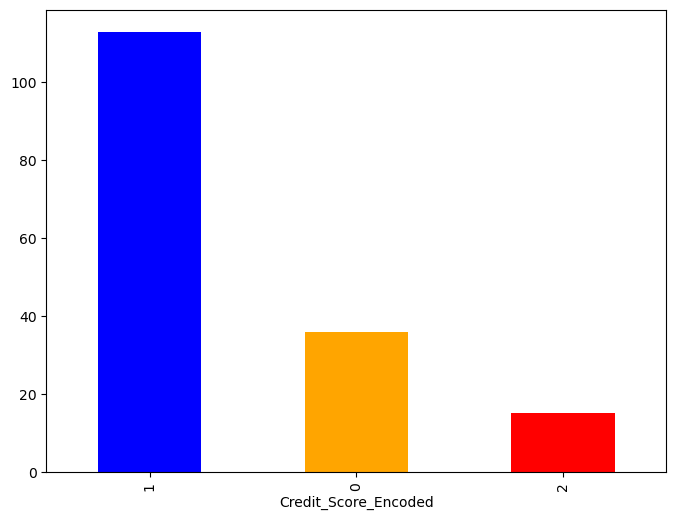

In [154]:
# Verificando o balanceamento

score_counts = df['Credit_Score_Encoded'].value_counts()
plt.figure(figsize=(8, 6))
score_counts.plot(kind='bar', color=['blue', 'orange', 'red'])

plt.show()

In [156]:
# Calcular e imprimir as porcentagens dos valores da coluna 'Credit_Score_Encoded'

print((df['Credit_Score_Encoded'].value_counts(normalize=True) * 100))

Credit_Score_Encoded
1    68.902439
0    21.951220
2     9.146341
Name: proportion, dtype: float64


In [ ]:
# 68% corresponde ao alto credito, 21% ao médio e 9% ao baixo limite

In [ ]:
# H) Vamos realizar o balancecamento dos dados da coluna de credit score.
# Se lembre que realizazmos apenas para a base de treino.

In [163]:
# Balanceamento - SMOTE

# Criar uma instância do SMOTE
smote = SMOTE(random_state=42)

# Aplicar o SMOTE aos dados de treinamento (X_train, Y_train)
X_train_balanced, Y_train_balanced = smote.fit_resample(X_train, Y_train)

# Verificar a distribuicao das classes apos o balanceamento
print('Distriuicao das classes apois o balanceamento:')
print(Y_train_balanced.value_counts())

Distriuicao das classes apois o balanceamento:
Credit_Score_Encoded
0    84
2    84
1    84
Name: count, dtype: int64


In [164]:
train_balance = Y_train_balanced.value_counts()
print('Balanceamento em Y_train:')
print(train_balance)

Balanceamento em Y_train:
Credit_Score_Encoded
0    84
2    84
1    84
Name: count, dtype: int64
